In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.colors as mcolors

In [2]:
colors = ['grey', 'green', 'red']
cmap = mcolors.LinearSegmentedColormap.from_list("my_cmap", colors)

In [3]:
file = open("2dca_output.txt")
fileString = file.read().split("\n")
file.close()

In [4]:
shape = [int(x) for x in fileString[0].split()]
iterations = len(fileString) - 1
structure = iterations, shape[0], shape[1]
CAs = np.zeros(structure)
for i in range(iterations):
  CAs[i, :, :] = np.array([int(x) for x in fileString[i+1].split()]).reshape(structure[1:])
structure

(151, 30, 30)

Plot each interation of the CA

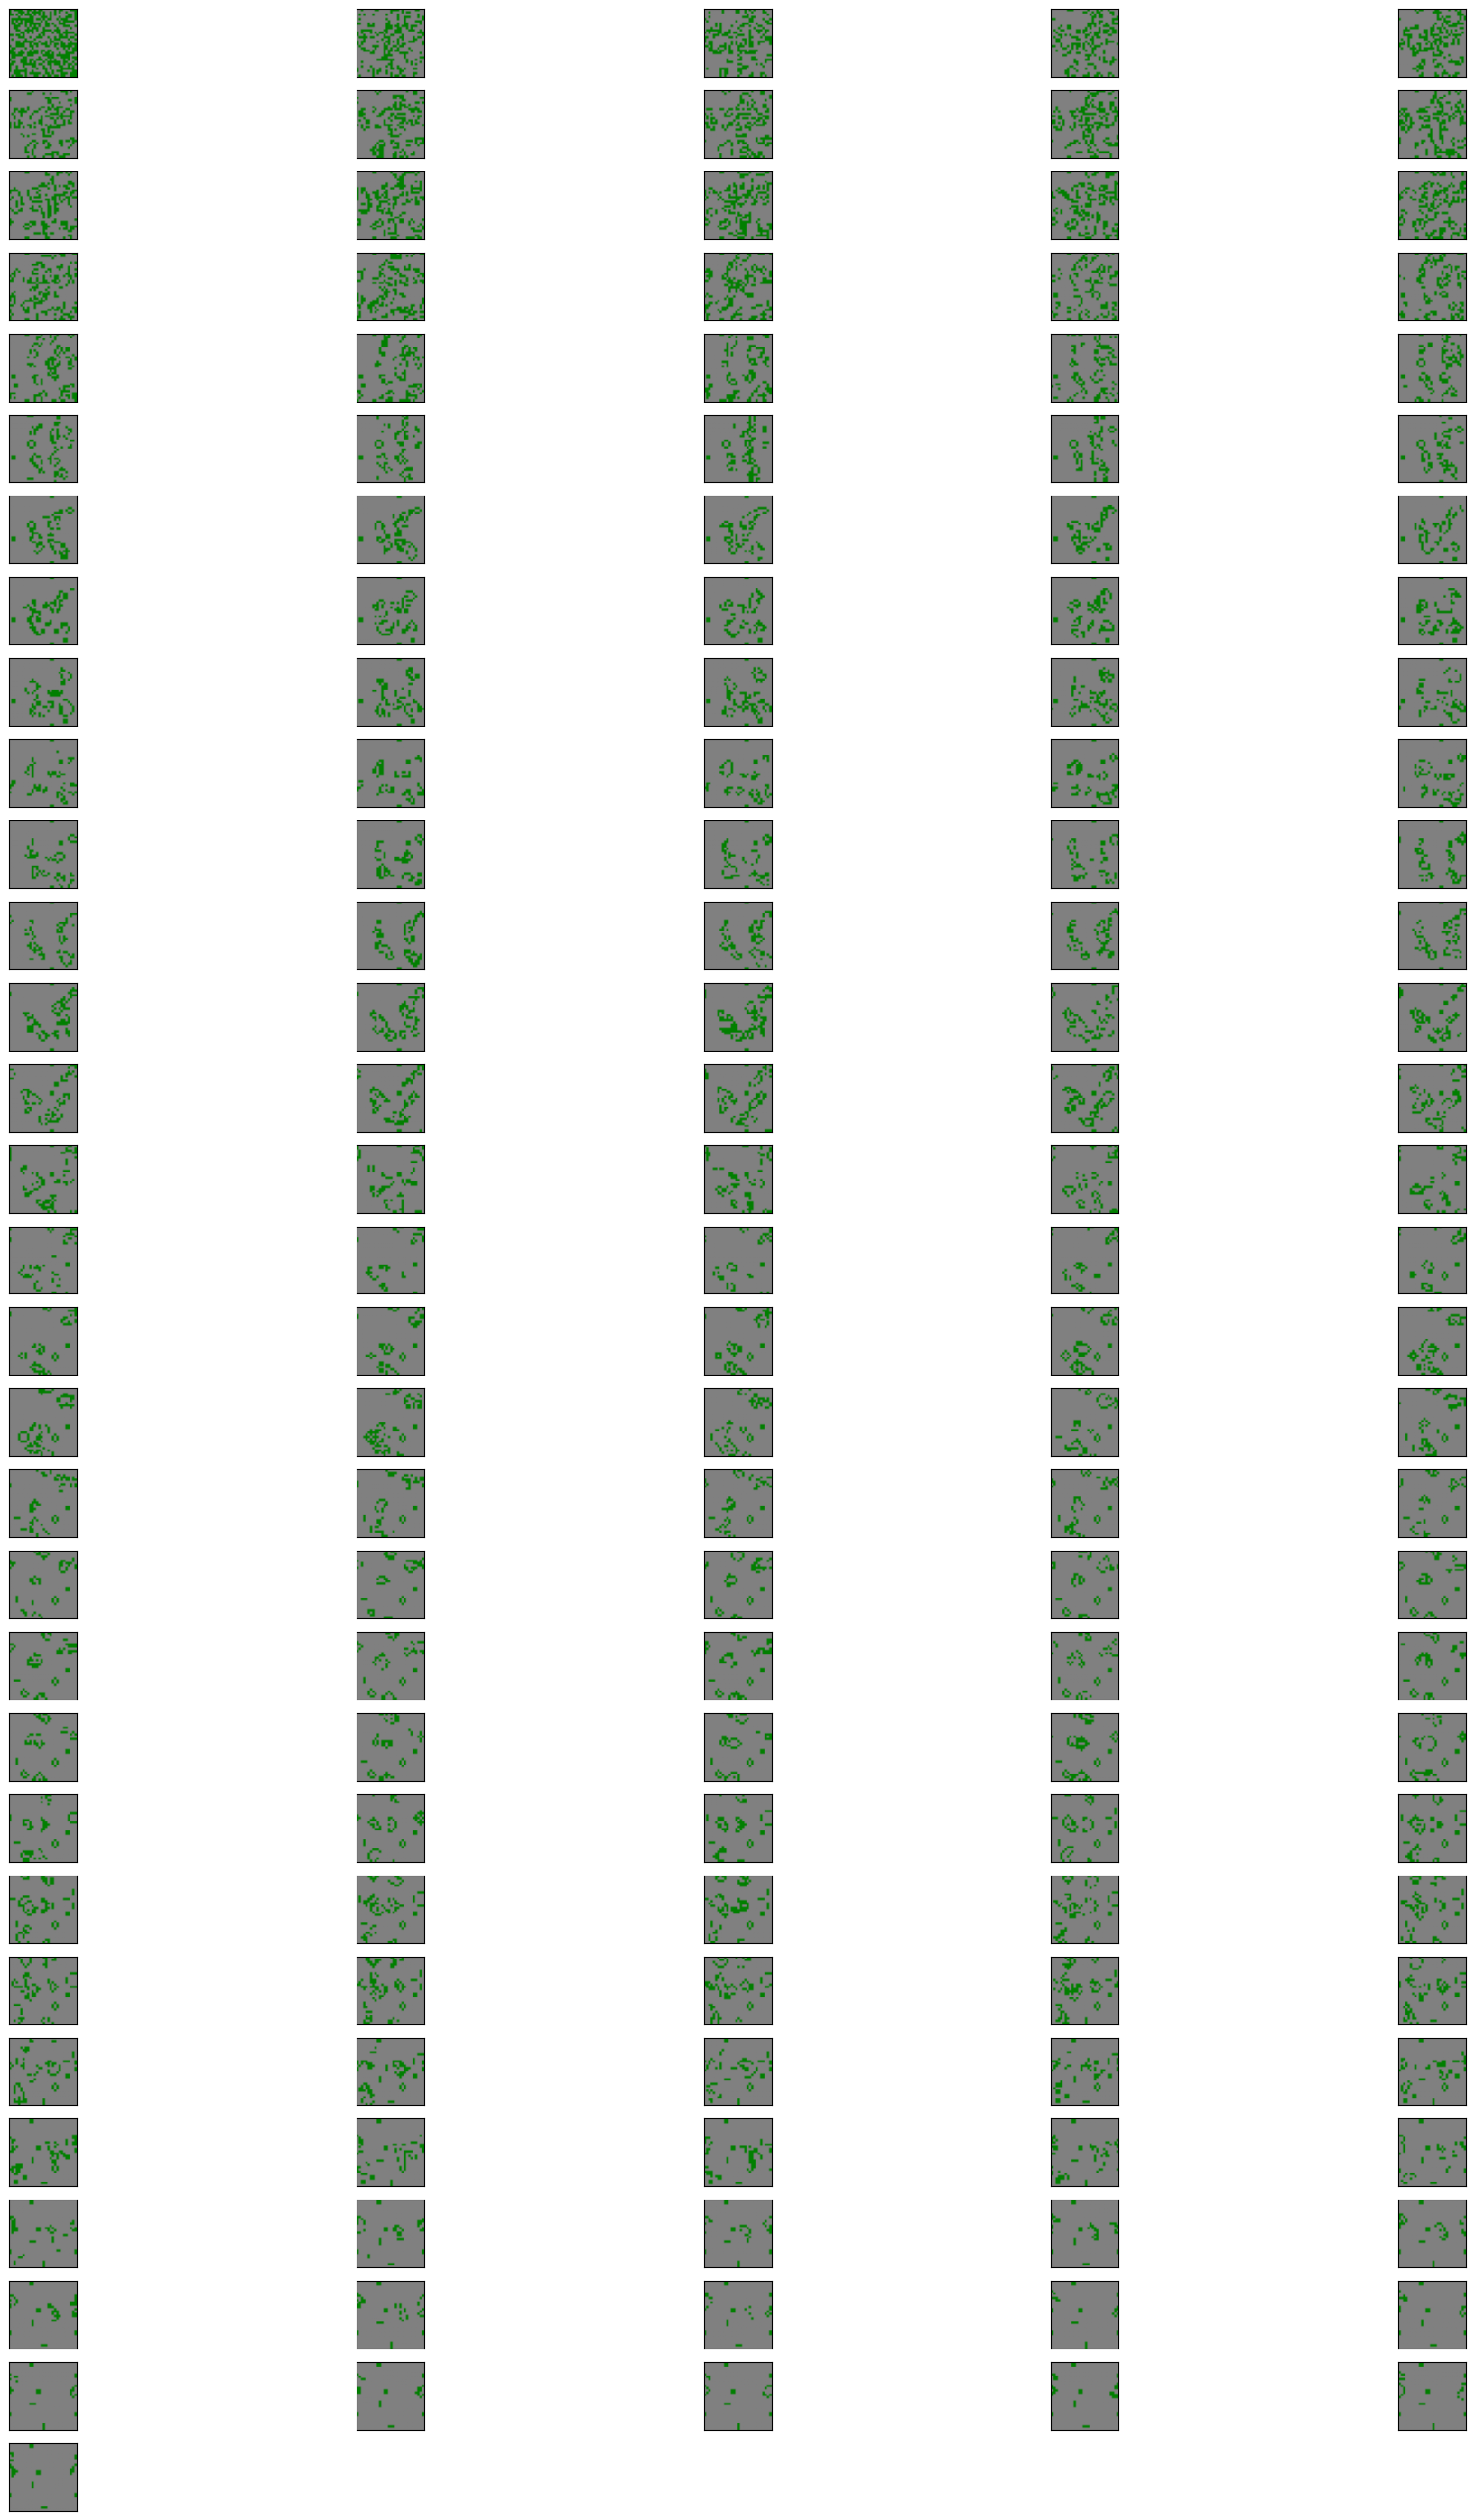

In [5]:
figure_width = 5
figure_height = iterations//figure_width + 1
fig, ax = plt.subplots(figure_height, figure_width, figsize=[24,36])
for i in range(iterations):
  ax[i//figure_width, i % figure_width].imshow(CAs[i], vmin=0, vmax=2, cmap=cmap)
  ax[i//figure_width, i % figure_width].set_xticks([])
  ax[i//figure_width, i % figure_width].set_yticks([])
for i in range(iterations, figure_width*figure_height):
  ax[i//figure_width, i % figure_width].remove()
plt.show()

In [6]:
from matplotlib import rc
rc('animation', html='jshtml')

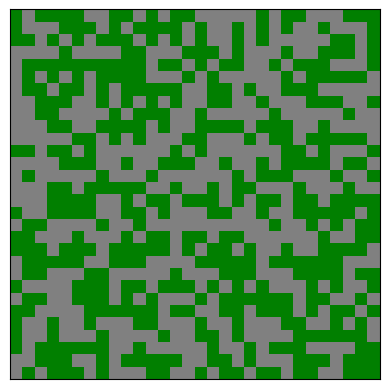

In [7]:
fig, ax = plt.subplots()

ims = []
for i in range(iterations):
  ax.set_xticks([])
  ax.set_yticks([])
  im = ax.imshow(CAs[i], animated=True, vmin=0, vmax=2, cmap=cmap)
  if i == 0:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(CAs[i], vmin=0, vmax=2, cmap=cmap)  # show an initial one first
  ims.append([im])

ani = animation.ArtistAnimation(fig, ims, blit=True)

In [8]:
ani

Compare to Benchmark code from https://cppscripts.com/conways-game-of-life-cpp

In [9]:
BM_file = open("2dca_benchmark_output.txt")
BM_fileString = BM_file.read().split("\n")
BM_shape = [int(x) for x in BM_fileString[0].split()]
BM_iterations = len(BM_fileString) - 1
BM_structure = BM_iterations, BM_shape[0], BM_shape[1]
BM_CAs = np.zeros(BM_structure)
for i in range(iterations):
  BM_CAs[i, :, :] = np.array([int(x) for x in BM_fileString[i+1].split()]).reshape(BM_shape)
BM_structure

(151, 30, 30)

In [10]:
np.linalg.norm(BM_CAs - CAs)

np.float64(0.0)

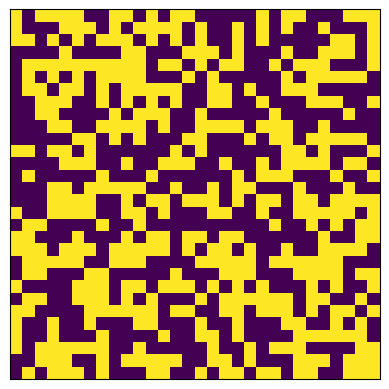

In [11]:
fig2, ax = plt.subplots()

ims = []
for i in range(iterations):
  ax.set_xticks([])
  ax.set_yticks([])
  im = ax.imshow(BM_CAs[i], animated=True)
  if i == 0:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(BM_CAs[i])
  ims.append([im])

ani2 = animation.ArtistAnimation(fig2, ims, blit=True)

In [12]:
ani2